# Introduction: Vertical Modes of the Tropical Atmosphere
In this notebook we will
- Compute the vertical normal modes of the tropical atmosphere
- Visualize these vertical modes
- Use these vertical modes to explore the regional variantions in climatalogical divergence profiles.

This notebook is intended as a supplement to the lecture notes included in this Google Drive folder.

Students are welcome to copy and distribute this notebook as desired. Please direct questions to pedro.anguloumana at gmail dot com.

맛있게 드세요~

In [ ]:
# Colab: the line below installs the two packages that aren't preinstalled.
# Running locally: skip it and install cartopy + gdown into your env first
# (conda recommended for cartopy's GEOS/PROJ binaries).!pip install cartopy gdown 
import xarray as xr
xr.set_options(keep_attrs=False)
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 30.8 MB/s eta 0:00:00


# Constant $N^2$

# Downloading and preparing data
We will use a dataset of monthly temperature and vertical pressure velocity ($\omega$) profiles over the global tropics (20S to 20N) at 1 degree resolution, obtained from ERA5 reanalysis.

We will also define a number of relevant physical constants, and isolate the pressure grid that will serve as our vertical coordinate.

In [ ]:
def download_data_from_link(file_link, output_name):
  file_id = file_link.split('/')[-2]
  gdown.download(f"https://drive.google.com/uc?id={file_id}", output_name, quiet=False)

temperature_file_link = "https://drive.google.com/file/d/1iF1eyFHu4Npj7gl0RSko5vhtsKJVJoDo/view?usp=sharing"
download_data_from_link(temperature_file_link, 'temperature.nc')

omega_file_link = "https://drive.google.com/file/d/1B17JZmd90B3o3Pc9MGjWoGMHO2xHJa8v/view?usp=sharing"
download_data_from_link(omega_file_link, 'omega.nc')

Downloading...
From (original): https://drive.google.com/uc?id=1iF1eyFHu4Npj7gl0RSko5vhtsKJVJoDo
From (redirected): https://drive.google.com/uc?id=1iF1eyFHu4Npj7gl0RSko5vhtsKJVJoDo&confirm=t&uuid=a90f9b5b-1e12-469f-99ad-12d120ade2d0
To: /content/temperature.nc
100%|██████████| 263M/263M [00:06<00:00, 41.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1B17JZmd90B3o3Pc9MGjWoGMHO2xHJa8v
From (redirected): https://drive.google.com/uc?id=1B17JZmd90B3o3Pc9MGjWoGMHO2xHJa8v&confirm=t&uuid=bb61f92c-3105-4b29-b725-46de87bf9cc0
To: /content/omega.nc
100%|██████████| 263M/263M [00:03<00:00, 73.9MB/s]


In [ ]:
temperature_da = (
    xr.open_dataarray('./temperature.nc')
    .sel(pressure_level=slice(1000, 100))
    .sortby('pressure_level')
)
display(temperature_da)

omega_da = (
    xr.open_dataarray('./omega.nc')
    .sel(pressure_level=slice(1000, 100))
    .sortby('pressure_level')
)
display(omega_da)

<xarray.DataArray 't' (valid_time: 120, pressure_level: 27, lat: 41, lon: 360)> Size: 191MB
[47822400 values with dtype=float32]
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 960B 2010-01-01 ... 2019-12-01
  * pressure_level  (pressure_level) float64 216B 100.0 125.0 ... 975.0 1e+03
  * lat             (lat) float64 328B -20.0 -19.0 -18.0 ... 18.0 19.0 20.0
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Attributes: (12/31)
    standard_name:                            air_temperature
    long_name:                                Temperature
    units:                                    K
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    ...                                       ...
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Temperature
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K

<xarray.DataArray 'w' (valid_time: 120, pressure_level: 27, lat: 41, lon: 360)> Size: 191MB
[47822400 values with dtype=float32]
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 960B 2010-01-01 ... 2019-12-01
  * pressure_level  (pressure_level) float64 216B 100.0 125.0 ... 975.0 1e+03
  * lat             (lat) float64 328B -20.0 -19.0 -18.0 ... 18.0 19.0 20.0
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Attributes: (12/31)
    standard_name:                            lagrangian_tendency_of_air_pres...
    long_name:                                Vertical velocity
    units:                                    Pa s**-1
    GRIB_paramId:                             135
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    ...                                       ...
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Vertical velocity
    GRIB_shortName:                           w
    GRIB_totalNumber:                         0
    GRIB_units:                               Pa s**-1

In [ ]:
# Pull out the pressure data for convenience
# Also check that our two datasets are on the same pressure grid
assert((temperature_da.pressure_level == omega_da.pressure_level).all())
p = temperature_da.pressure_level   # hPa

# Physical constants
R_d   = 287.0      # J / (kg K)
c_p   = 1004.0     # J / (kg K)
g     = 9.81       # m / s^2
kappa = R_d / c_p  # dimensionless
p0    = 1000.0     # hPa  (reference pressure for potential temperature)

# Constant $N^2$
If we assume $N^2$ is a constant, then we can directly compute the theoretical baroclinic mode structures

In [ ]:
# Compute N^2
T = temperature_da.mean(('valid_time', 'lat', 'lon'))
potential_temperature = T * (p0 / p) ** kappa
dtheta_dp = potential_temperature.differentiate('pressure_level')
N2 = -(g**2 * p) / (R_d * T * potential_temperature) * dtheta_dp
N2_avg = N2.mean('pressure_level').rename('AvgN2')
display(N2_avg)

# Compute Scale Height
H_s = (R_d * T.mean() / g).rename('ScaleHeight')
display(H_s)

# Compute log-p coordinates
# Compute zB and zT
z = -H_s * np.log(p/p0)
z = z.sortby(z) # ascending in z, pressure_level coord rides along
zB, zT = z.min(), z.max()
print(f"zB = {zB:.1f} m, zT = {zT:.1f} m")

<xarray.DataArray 'AvgN2' ()> Size: 8B
array(0.00013823)

<xarray.DataArray 'ScaleHeight' ()> Size: 8B
array(7686.24635593)

zB = -0.0 m, zT = 17698.2 m


## Building each mode
We will build each mode and normalize to unit norm $\langle \psi_n,\psi_n\rangle = \int_{z_B}^{z_T}\rho_0\,\psi_n^2\,dz = 1$,

In [ ]:
# Define convenience variables
rho0 = np.exp(-z/H_s)     # reference density (rho_s set to 1; it cancels after normalization)
L   = zT - zB
k   = 1.0/(2*H_s)

# Define the mass normalization
def mass_norm(psi):
    return np.sqrt(np.abs(np.trapezoid(rho0 * psi * psi, z)))

# Compute the barotropic mode
psi0 = np.ones_like(z)
psi0 /= mass_norm(psi0)

# Compute the baroclinic mode
# Returns (m_n, lambda_n, he_n, psi_n(z)) for baroclinic mode n>=1
def baroclinic_mode(n):
    m  = n*np.pi/L
    cB, sB = np.cos(m*zB), np.sin(m*zB)
    # null vector of the (corrected) boundary-condition matrix
    C  =  (m*cB + k*sB)
    D  = -(k*cB - m*sB)
    psi = np.exp(z/(2*H_s))*(C*np.cos(m*z) + D*np.sin(m*z))
    psi /= mass_norm(psi)
    if psi[np.argmax(np.abs(psi.values))] < 0:   # sign convention
        psi *= -1
    lam = (m**2 + 1.0/(4*H_s**2))/N2_avg
    he  = 1.0/(g*lam)
    return m.item(), lam.item(), he.item(), psi

## Compute equivalent depth and phase speed spectrum

In [ ]:
# Initialize a dict of columns to build into a dataframe
data = {
    'n': [],
    'm_n [1/m]': [],
    'lambda_n [s^2/m^2]': [],
    'h_e,n [m]': [],
    'c_n [m/s]': []
}

# Barotropic mode (n=0)
# We manually set the equivalent depth as infinity
data['n'].append(0)
data['m_n [1/m]'].append(0.0)
data['lambda_n [s^2/m^2]'].append(0.0)
data['h_e,n [m]'].append(np.inf)
data['c_n [m/s]'].append(np.inf)

# baroclinic modes
for n in range(1, 6):
    m, lam, he, _ = baroclinic_mode(n)
    data['n'].append(n)
    data['m_n [1/m]'].append(m)
    data['lambda_n [s^2/m^2]'].append(lam)
    data['h_e,n [m]'].append(he)
    data['c_n [m/s]'].append(np.sqrt(g*he))

df = pd.DataFrame(data).set_index('n')
df

,m_n [1/m],lambda_n [s^2/m^2],"h_e,n [m]",c_n [m/s]
n,,,,
0,0.000000,0.000000,inf,inf
1,0.000178,0.000259,394.247799,62.189797
2,0.000355,0.000942,108.167015,32.574813
3,0.000533,0.002082,48.957754,21.915190
4,0.000710,0.003678,27.717024,16.489512
5,0.000888,0.005729,17.792211,13.211419


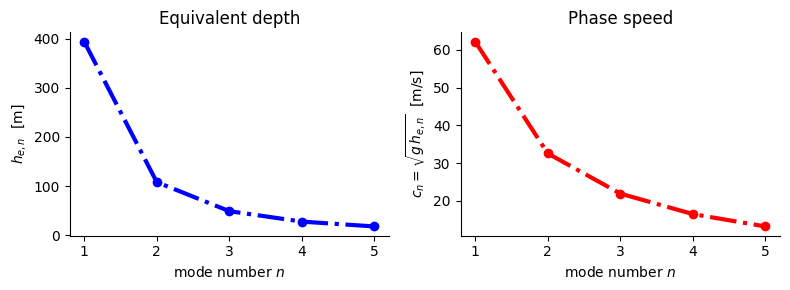

In [ ]:
# Baroclinic modes only (n>=1); the n=0 row is inf and can't be plotted
dfb = df[np.isfinite(df['c_n [m/s]'])]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3))
# Plot equivalent depths
a1.plot(dfb.index, dfb['h_e,n [m]'], 'o-.', color='blue', lw=3)
a1.set_xlabel('mode number $n$')
a1.set_ylabel(r'$h_{e,n}$  [m]')
a1.set_yscale('linear')
a1.set_xticks(dfb.index)
a1.set_title('Equivalent depth')
a1.spines[['top', 'right']].set_visible(False)

# Plot phase speeds
a2.plot(dfb.index, dfb['c_n [m/s]'], 'o-.', color='red', lw=3)
a2.set_xlabel('mode number $n$')
a2.set_ylabel(r'$c_n=\sqrt{g\,h_{e,n}}$  [m/s]')
a2.set_xticks(dfb.index)
a2.set_title('Phase speed')
a2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('./depth_and_speed.pdf', format='pdf')

plt.show()

## Compute each baroclinic mode

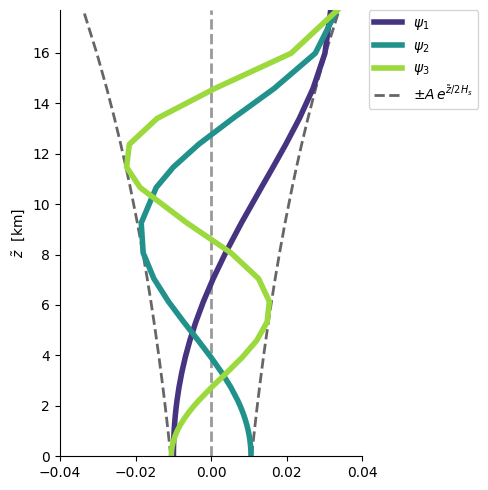

In [ ]:
n_modes = 3
fig, ax = plt.subplots(figsize=(5,5))
# ax.plot(psi0, z/1000, lw=4, color='k', label=r'$\psi_0$ (barotropic)')
colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_modes))

env_amp = 0.0  # track largest envelope amplitude among plotted modes
for n in range(1, n_modes+1):
    m, _, _, psi = baroclinic_mode(n)
    ax.plot(psi, z/1000, lw=4, color=colors[n-1], label=fr'$\psi_{n}$')
    # recover the normalized amplitude A of the enclosed sinusoid for this mode
    cB, sB = np.cos(m*zB), np.sin(m*zB)
    C, D = (m*cB + k*sB), -(k*cB - m*sB)
    raw = np.exp(z/(2*H_s))*(C*np.cos(m*z) + D*np.sin(m*z))
    A = np.hypot(C, D)/mass_norm(raw)
    env_amp = max(env_amp, A)

# draw the envelope for the largest-amplitude mode
env = env_amp*np.exp(z/(2*H_s))
ax.plot( env, z/1000, lw=2, ls='--', color='0.4', label=r'$\pm A\,e^{\tilde z/2H_s}$', zorder=0)
ax.plot(-env, z/1000, lw=2, ls='--', color='0.4', zorder=0)

ax.axvline(0, color='0.6', lw=2, linestyle='dashed', zorder=0)
ax.set_ylabel(r'$\tilde z$  [km]')
ax.set_ylim(zB/1000, zT/1000)
ax.set_xlim(-0.04, 0.04)
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.tight_layout()
# plt.savefig('./modes_profiles.pdf', format='pdf')
plt.show()


## Derivatives of Modes

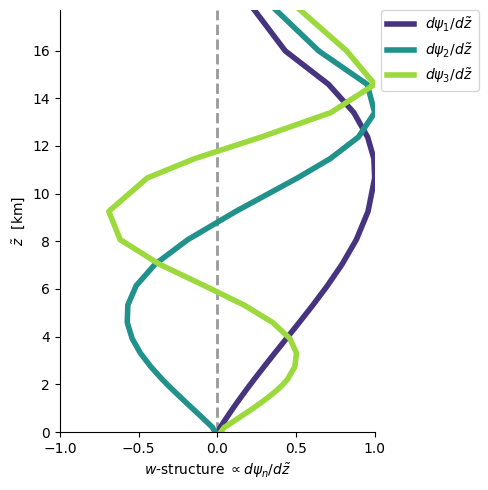

In [ ]:
n_modes = 3
fig, ax = plt.subplots(figsize=(5, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, 3))

for n in range(1, n_modes+1):
    _, _, _, psi = baroclinic_mode(n)
    w = np.gradient(psi, z)            # vertical-velocity structure ∝ dψ_n/dz̃
    w /= np.abs(w).max()               # peak-normalize so modes are comparable
    ax.plot(w, z/1000, lw=4, color=colors[n-1], label=fr'$d\psi_{n}/d\tilde z$')

ax.axvline(0, color='0.6', lw=2, linestyle='dashed', zorder=0)
ax.set_ylabel(r'$\tilde z$  [km]')
ax.set_xlabel(r'$w$-structure $\propto d\psi_n/d\tilde z$')
ax.set_ylim(zB/1000, zT/1000)
ax.set_xlim(-1, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.tight_layout()
plt.savefig('./deriv_modes_profiles.pdf', format='pdf')

plt.show()

# Non-constant $N^2$

## Computing $S(p)$ and $a(p)$
As discussed in the notes, we aim to compute approximations to the eigenfunctions of the *vertical structure operator*

$$
L[\phi] = \frac{\partial}{\partial p}\left(a(p)\frac{\partial \phi}{\partial p}\right)
$$

Where
$$
a(p) = \frac{p}{SR_d}
$$

is a function of the *static stability*
$$
S(p)=-\frac{T}{\theta}\frac{\partial\theta}{\partial p}
$$

We will compute the climatological $a(p)$ of the global tropics to obtain vertical normal modes (eigenvectors of the discretized $L$) based on the average vertical stratification of the global tropics.

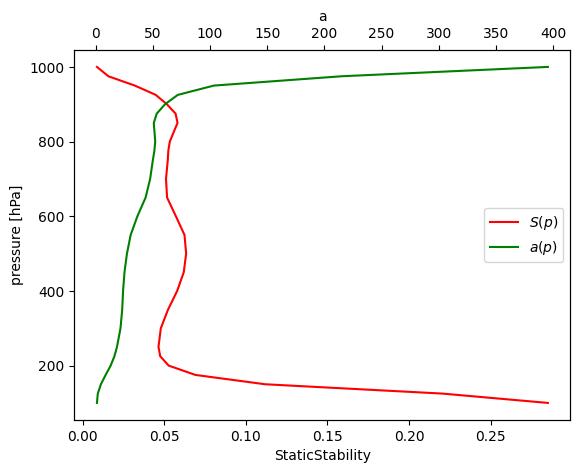

In [ ]:
T = temperature_da.mean(('valid_time', 'lat', 'lon'))
potential_temperature = T * (p0 / p) ** kappa
dtheta_dp = potential_temperature.differentiate('pressure_level')
S = (-1 * T / potential_temperature * dtheta_dp).rename('StaticStability')
a = (p / (S * R_d )).rename('a')

# Quick plot of the static stability and a
fig, ax = plt.subplots()
S.plot(ax=ax, y='pressure_level', label=r'$S(p)$', color='red')
ax.invert_yaxis()
ax2 = ax.twiny()
a.plot(ax=ax2, y='pressure_level', label=r'$a(p)$', color='green')
ax2.invert_yaxis()

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='center right')

## Buidling the stiffness and mass matricies
Recall from the notes that we want to solve the generalized eigenvalue problem


$$
K\phi = -\lambda M\phi
$$


Where $K$ (the *stiffness matrix*) has diagonal elements

$$
K_{ii} =
\begin{cases}
\dfrac{a_{1/2}}{\Delta p_0}, & i = 1, \\[6pt]
\dfrac{a_{i-1/2}}{\Delta p_{i-1}} + \dfrac{a_{i+1/2}}{\Delta p_i}, & 2 \le i \le n-1, \\[6pt]
\dfrac{a_{n-3/2}}{\Delta p_{n-2}}, & i = n.
\end{cases}
$$
And off-diagonal elements
$$
K_{i,i+1} \;=\; K_{i+1,i} \;=\; -\,\dfrac{a_{i+1/2}}{\Delta p_i}, \qquad 1 \le i \le n-1.
$$

While $M$ (the *mass matrix*) has diagonal elements
$$
M_{ii} =
\begin{cases}
\dfrac{\Delta p_0}{3}, & i = 1, \\[6pt]
\dfrac{\Delta p_{i-1} + \Delta p_i}{3}, & 2 \le i \le n-1, \\[6pt]
\dfrac{\Delta p_{n-2}}{3}, & i = n.
\end{cases}
$$
And off-diagonal elements
$$
M_{i,i+1} = M_{i+1,i} \;=\; \dfrac{\Delta p_i}{6}, \qquad 1 \le i \le n-1.
$$

The extra special cases at $i=1$ and $i=n$ in the diagonal cases arise because, at the boundaries, there is only one hat basis function over the intervals $[p_1, p_2]$ and $[p_n-1, p_n]$, respectively.

In [ ]:
# First chop up the pressure coordinate into intervals
p_values = p.data
dp = np.diff(p_values)

# Compute the midpoints of a(p) for each interval
# (corresponding to the fractional indicies)
a_values = a.data
a_half = 0.5 * (a_values[:-1] + a_values[1:])


# Initalize K and M
N = len(p)
K = np.zeros((N, N))
M  = np.zeros((N, N))


# Build K
for i in range(1, N - 1):
    k_minus = a_half[i - 1] / dp[i - 1]
    k_plus  = a_half[i]     / dp[i]

    K[i, i - 1] = -k_minus
    K[i, i]     =  k_minus + k_plus
    K[i, i + 1] = -k_plus

# For the boundaries, slight tweaking, since the hat functions don't overlap
k_top = a_half[0] / dp[0]
K[0, 0] = k_top
K[0, 1] = -k_top

k_bot = a_half[-1] / dp[-1]
K[-1, -2] = -k_bot
K[-1, -1] = k_bot


# Compute the mass matrix M
for i in range(1, N - 1):
    M[i, i] = (dp[i - 1] + dp[i]) / 3.0
# Boundary diagonal entries
M[0, 0]         = dp[0]    / 3.0
M[-1, -1]       = dp[-1]   / 3.0
# Off-diagonal entries (tridiagonal)
for i in range(N - 1):
    M[i,   i+1] = dp[i] / 6.0
    M[i+1, i  ] = dp[i] / 6.0

# To make sure the matrix is symmetric (cleans up rounding errors)
K = 0.5 * (K + K.T)
M = 0.5 * (M + M.T)

## Computing the normal modes
We now compute the vertical modes by finding vectors $\phi$ that satisfy
$$
K\phi = -\lambda M\phi
$$

First (barotropic) eigenvalue: -3.308e-17
  (should be ~0 to within roundoff; magnitude here is ~3e-17)

First 5 internal-mode eigenvalues:
[0.00035491 0.00130433 0.00260427 0.00459665 0.00743054]

First 5 phase speeds (m/s):
[53.08093579 27.68894446 19.5955277  14.74956979 11.60084897]

First 5 equivalent depths (m):
[287.21567225  78.15266519  39.14217185  22.17633119  13.71862353]


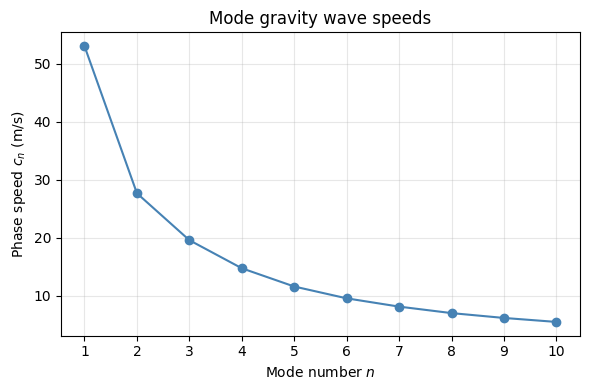

In [ ]:
# Solve the generalized eigenproblem
eigen_vals, eigen_vecs = scipy.linalg.eigh(K, M)

# Sort the eigenvalues in ascending order
# Sort eigenvectors in corresponding order
idx = np.argsort(eigen_vals)
eigen_vals = eigen_vals[idx]
eigen_vecs = eigen_vecs[:, idx]
# Apply sign convention to eigen_vecs: make the largest lobe positive
peak = np.argmax(np.abs(eigen_vecs), axis=0)            # row of largest |value| in each column
signs = np.sign(eigen_vecs[peak, np.arange(eigen_vecs.shape[1])])
eigen_vecs *= signs

# There is a special n=0 mode that arises, corresponding to a constant profile.
# This is the so-called "barotropic mode" with formally infinite wave speed.
# We expect its eigenvalue to be zero, up to floating-point roundoff.
print(f"First (barotropic) eigenvalue: {eigen_vals[0]:.3e}")
print(f"  (should be ~0 to within roundoff; magnitude here is ~{abs(eigen_vals[0]):.0e})")

# Discard the barotropic mode, keeping the same variable names
eigen_vals = eigen_vals[1:]
eigen_vecs = eigen_vecs[:, 1:]

# Now compute wave speeds and equivalent depths for the internal modes
c = 1.0 / np.sqrt(eigen_vals)
h = c**2 / g

print("\nFirst 5 internal-mode eigenvalues:")
print(eigen_vals[:5])
print("\nFirst 5 phase speeds (m/s):")
print(c[:5])
print("\nFirst 5 equivalent depths (m):")
print(h[:5])

# Plot the wave speeds of the first several internal modes
n_plot = min(10, len(c))
mode_numbers = np.arange(1, n_plot + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mode_numbers, c[:n_plot], 'o-', color='steelblue')
ax.set_xlabel("Mode number $n$")
ax.set_ylabel("Phase speed $c_n$ (m/s)")
ax.set_title("Mode gravity wave speeds")
ax.set_xticks(mode_numbers)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plotting the vertical modes
We plot the vertical modes as vertical profiles. Since the magntiude is arbitrary, we normalize each eigenvector to have maximum amplitude of 1.

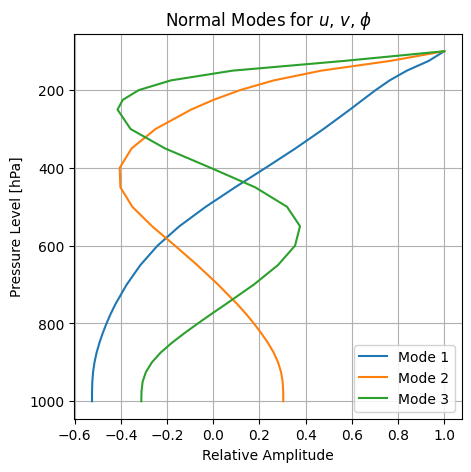

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
for mode_num in range(1, 4):
  unnormed_mode = eigen_vecs[:, mode_num-1]
  normed_mode = unnormed_mode / max(abs(unnormed_mode))
  ax.plot(normed_mode, p, label=f"Mode {mode_num}")
ax.legend(framealpha=0.85)
ax.invert_yaxis()
ax.set_ylabel('Pressure Level [hPa]')
ax.set_xlabel('Relative Amplitude')
ax.set_title(r'Normal Modes for $u$, $v$, $\phi$')
ax.grid()


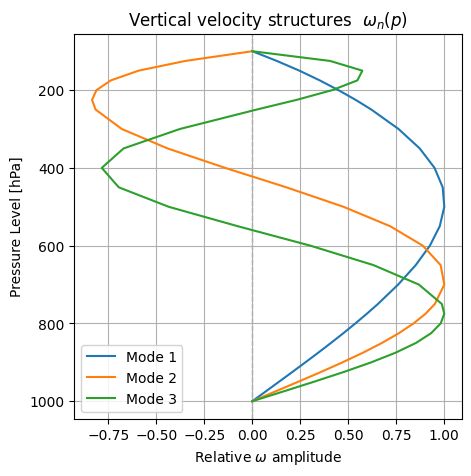

In [ ]:
from scipy.integrate import cumulative_trapezoid

fig, ax = plt.subplots(figsize=(5, 5))
p_vals = p.values   # hPa

for mode_num in range(1, 4):
    psi = eigen_vecs[:, mode_num-1]                    # structure of divergence / (u,v,φ)
    # Continuity: ∂ω/∂p = -∇·v  ->  ω(p) = -∫ ∇·v dp
    # The divergence shares the mode's structure ψ, so the vertical-velocity
    # structure is the cumulative vertical integral of the mode.
    w = -scipy.integrate.cumulative_trapezoid(psi, p_vals, initial=0.0)
    if w[np.argmax(np.abs(w))] < 0:                    # same "largest lobe positive" convention
        w = -w
    w = w / max(abs(w))                                # normalize each to its own peak (shape only)
    ax.plot(w, p_vals, label=f"Mode {mode_num}")

ax.axvline(0, color='0.6', lw=1, ls='--', zorder=0)
ax.legend(framealpha=0.85)
ax.invert_yaxis()
ax.set_ylabel('Pressure Level [hPa]')
ax.set_xlabel(r'Relative $\omega$ amplitude')
ax.set_title(r'Vertical velocity structures  $\omega_n(p)$')
ax.grid()

## How much variance is explained by these modes?
We now consider how much variance in climatalogical vertical divergence can be explained by each of these modes for different regions of the world.

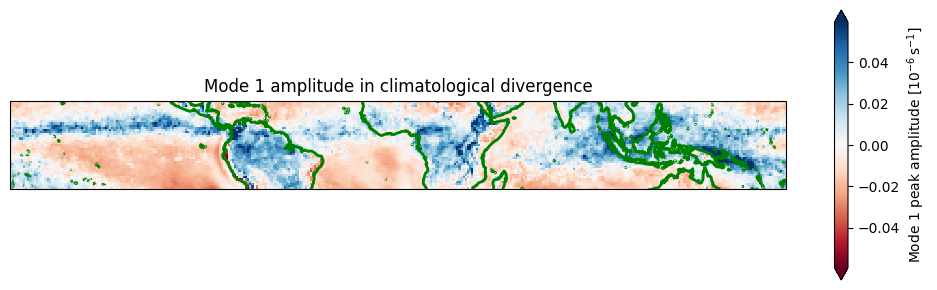

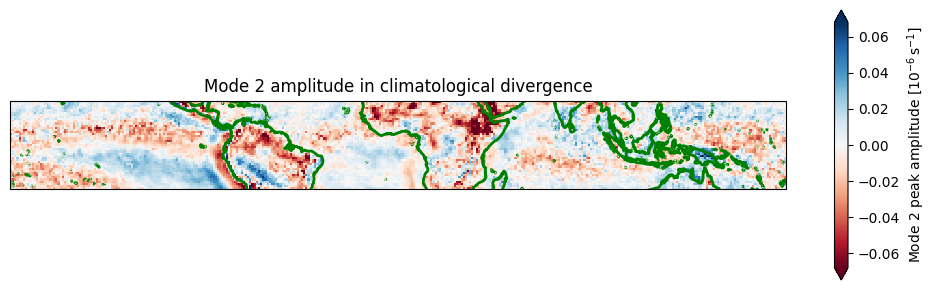

In [ ]:
# Compute divergence from omega
div = -omega_da.differentiate('pressure_level').rename('divergence') * 1e2
div_clim = div.mean('valid_time')

# Project climatological divergence onto the internal modes at every column.
#
# Strategy: vectorize over (lat, lon) so we don't loop in Python.
# Use transpose to ensure div_clim has shape (pressure_level, lat, lon).
# Reshape to (pressure_level, n_columns), do the linear algebra, reshape back.

# Extract divergence values as a numpy array, with pressure as the first axis
F = div_clim.transpose('pressure_level', 'lat', 'lon').data
n_p, n_lat, n_lon = F.shape
F_flat = F.reshape(n_p, n_lat * n_lon) # shape (n_p, n_columns)

# Modal coefficients at every column:
# coeffs[n, c] = ψ_n.T x M x F[:, c]
coeffs = eigen_vecs.T @ M @ F_flat     # shape (n_modes, n_columns)

# Rescale: multiply each mode's amplitude by the mode's peak value, so that
# the resulting coefficient has units of s^-1 and is interpretable as the
# peak divergence (anywhere in the column) attributable to that mode.
psi_max = np.max(np.abs(eigen_vecs), axis=0)  # shape (n_modes,)
coeffs_phys = coeffs * psi_max[:, np.newaxis] # shape (n_modes, n_columns)

# Reshape and wrap as a DataArray
coeffs_3d = coeffs_phys.reshape(coeffs.shape[0], n_lat, n_lon)
modal_amplitude = xr.DataArray(
    coeffs_3d,
    dims=('mode', 'lat', 'lon'),
    coords={
        'mode': np.arange(1, coeffs.shape[0] + 1),
        'lat':  div_clim.lat,
        'lon':  div_clim.lon,
    },
    name='modal_amplitude',
    attrs={'units': 's^-1', 'long_name': 'Peak modal divergence amplitude'},
)

# Plot in units of 10^-6 s^-1 for readability
n_modes_plot = 2
scale = 1

for n in range(n_modes_plot):
    fig, ax = plt.subplots(figsize=(10, 3), subplot_kw={'projection': ccrs.PlateCarree()})
    field = modal_amplitude.sel(mode=n + 1) * scale
    vmax = float(np.nanpercentile(np.abs(field), 99))   # robust to outliers

    field.plot(
        ax=ax,
        x='lon', y='lat',
        vmin=-vmax, vmax=vmax,
        cmap='RdBu',
        add_colorbar=True,
        cbar_kwargs={'label': rf'Mode {n+1} peak amplitude [$10^{{-6}}\,$s$^{{-1}}$]'},
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(f"Mode {n + 1} amplitude in climatological divergence")
    ax.coastlines(color='green', linewidth=2)
    plt.tight_layout()
    plt.show()

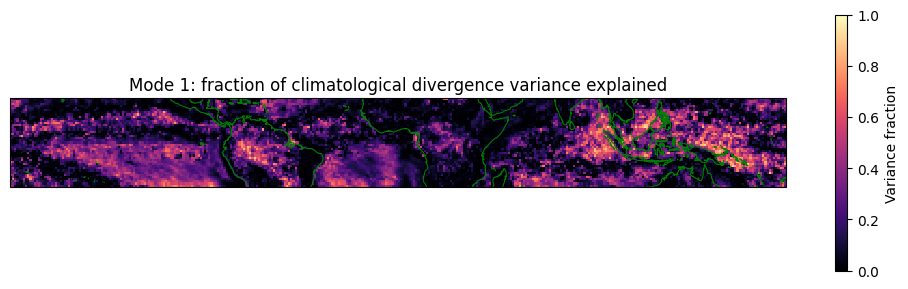

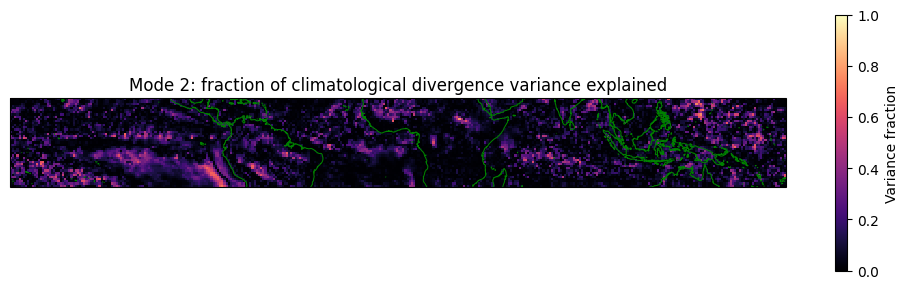

In [ ]:
## Compute divergence from omega
div = -omega_da.differentiate('pressure_level').rename('divergence')
div_clim = div.mean('valid_time')

# Project climatological divergence onto the internal modes at every column,
# and compute the per-mode explained variance fraction as a 2D map.
#
# Strategy: vectorize over (lat, lon) so we don't loop in Python.
# div_clim has shape (pressure_level, lat, lon).
# Reshape to (pressure_level, n_columns), do the linear algebra, reshape back.

# Extract divergence values as a numpy array, with pressure as the first axis
F = div_clim.transpose('pressure_level', 'lat', 'lon').data
n_p, n_lat, n_lon = F.shape
F_flat = F.reshape(n_p, n_lat * n_lon)         # shape (n_p, n_columns)

# Modal coefficients at every column:  coeffs[n, c] = ψ_n^T M F[:, c]
coeffs = eigen_vecs.T @ M @ F_flat              # shape (n_modes, n_columns)

# Per-column variance and per-mode squared coefficient
total_var_flat = np.einsum('ic,ij,jc->c', F_flat, M, F_flat)   # ||F[:,c]||_M^2
mode_var_flat  = coeffs**2                                      # shape (n_modes, n_columns)

# Fraction of variance explained by each mode at each column
frac_flat = mode_var_flat / total_var_flat[np.newaxis, :]      # shape (n_modes, n_columns)

# Reshape back to (n_modes, lat, lon)
frac = frac_flat.reshape(coeffs.shape[0], n_lat, n_lon)

# Wrap as an xarray DataArray for easy plotting
explained_variance = xr.DataArray(
    frac,
    dims=('mode', 'lat', 'lon'),
    coords={
        'mode': np.arange(1, coeffs.shape[0] + 1),
        'lat':  div_clim.lat,
        'lon':  div_clim.lon,
    },
    name='explained_variance_fraction',
)


# Plot maps for the first few modes
n_modes_plot = 2

for n in range(n_modes_plot):
  fig, ax = plt.subplots(
      figsize=(10, 3),
      subplot_kw={
          'projection': ccrs.PlateCarree()
          }
      )


  im = explained_variance.sel(mode=n + 1).plot(
      ax=ax,
      x='lon',
      y='lat',
      vmin=0,
      vmax=1,
      cmap='magma',
      add_colorbar=True,
      cbar_kwargs={'label': 'Variance fraction'},
      transform=ccrs.PlateCarree()
  )
  ax.set_title(f"Mode {n + 1}: fraction of climatological divergence variance explained")
  ax.set_xlabel("Longitude" if n == n_modes_plot - 1 else "")
  ax.set_ylabel("Latitude")
  ax.coastlines(color='green', linewidth=0.75)

  plt.tight_layout()
  plt.show()